## **1. Importing Libraries**

In [238]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import chi2
from sklearn.preprocessing import LabelEncoder


from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lifelines import KaplanMeierFitter

from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import learning_curve

from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.inspection import permutation_importance

from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored
from sksurv.util import Surv
from sksurv.linear_model import CoxPHSurvivalAnalysis

from patsy import dmatrix

## **2. Data Loading and Inspection**

In [195]:
pd.set_option('display.max_columns', None)
df = pd.read_csv(r"E:\XUL\FINALE\Fourth year\Proposal\Datasets\Kaggle.csv")
df.head()

,CHANNEL1,CHANNEL2,CHANNEL3,ENTRY AGE,SEX,POLICY TYPE 1,POLICY TYPE 2,POLICY TYPE 3,PAYMENT MODE,POLICY STATUS,BENEFIT,NON LAPSE GUARANTEED,SUBSTANDARD RISK,NUMBER OF ADVANCE PREMIUM,INITIAL BENEFIT,Full Benefit?,Policy Year (Decimal),Policy Year,Premium,Issue Date
0,1,1,1,36,F,1,1,A,Annually,Inforce,200000.0,NO NLG,0.0,0,0.0,N,8.000000,9,280.0,11-Aug
1,1,1,1,42,M,1,2,A,Annually,Inforce,100000.0,NO NLG,0.0,0,0.0,N,8.000000,9,200.0,11-Aug
2,1,1,2,40,M,2,3,A,Annually,Lapse,80000.0,NO NLG,0.0,0,0.0,N,8.000000,9,1289.0,11-Aug
3,1,1,3,39,M,1,2,A,Monthly,Lapse,100000.0,NO NLG,0.0,0,0.0,N,8.000000,9,216.0,11-Aug
4,1,1,4,44,M,1,2,A,Annually,Lapse,100000.0,NO NLG,0.0,0,0.0,N,7.916667,8,140.0,11-Sep


In [196]:
df.columns = (
  df.columns
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('?', '', regex=False)
)

In [197]:
df.shape

(185560, 20)

In [198]:
print("\nColumns:", df.columns.tolist())


Columns: ['channel1', 'channel2', 'channel3', 'entry_age', 'sex', 'policy_type_1', 'policy_type_2', 'policy_type_3', 'payment_mode', 'policy_status', 'benefit', 'non_lapse_guaranteed', 'substandard_risk', 'number_of_advance_premium', 'initial_benefit', 'full_benefit', 'policy_year_(decimal)', 'policy_year', 'premium', 'issue_date']


In [199]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185560 entries, 0 to 185559
Data columns (total 20 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   channel1                   185560 non-null  int64  
 1   channel2                   185560 non-null  int64  
 2   channel3                   185560 non-null  int64  
 3   entry_age                  185560 non-null  int64  
 4   sex                        185560 non-null  object 
 5   policy_type_1              185560 non-null  int64  
 6   policy_type_2              185560 non-null  int64  
 7   policy_type_3              185560 non-null  object 
 8   payment_mode               185560 non-null  object 
 9   policy_status              185560 non-null  object 
 10  benefit                    161896 non-null  float64
 11  non_lapse_guaranteed       185560 non-null  object 
 12  substandard_risk           185560 non-null  float64
 13  number_of_advance_premium  18

In [200]:
# Replacing -99 in SUBSTANDARD RISK with NaN so we can impute it
df['substandard_risk'] = df['substandard_risk'].replace(-99, np.nan)


In [201]:
# Renaming 'Policy Year (Decimal)' to represent  duration
df.rename(columns={'policy_year_(decimal)': 'duration'}, inplace=True)

In [202]:
#checking missing values
missing = df.isna().mean().sort_values(ascending=False)
missing[missing > 0]


premium             0.415650
benefit             0.127527
substandard_risk    0.000005
dtype: float64

In [203]:
# Handling missing values
imputer_mean = SimpleImputer(strategy='median')
numeric_features = ['premium', 'benefit', 'substandard_risk']
df[numeric_features] = imputer_mean.fit_transform(df[numeric_features])

## **3. Exploratory Data Analysis**

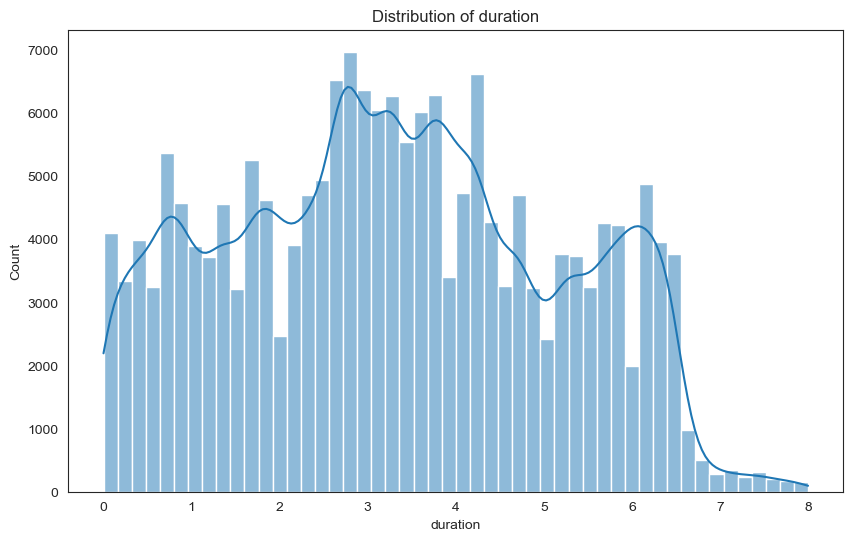

In [204]:
# Distribution of policy duration
plt.figure(figsize=(10,6))
sns.histplot(df['duration'], bins=50, kde=True)
plt.title('Distribution of duration')
plt.xlabel('duration')
plt.show()

This shows that early lapses are common for many policies <4 years

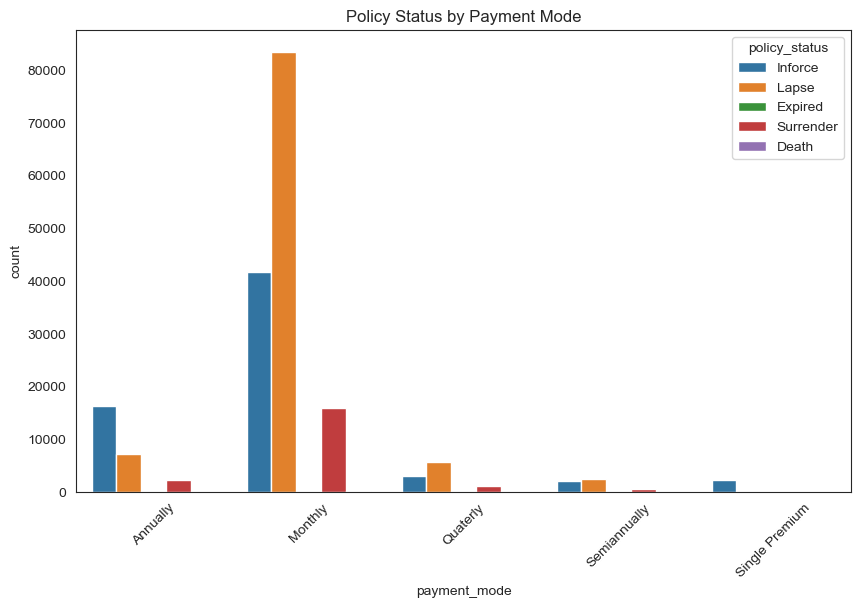

In [205]:
# Lapse rates by payment mode
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='payment_mode', hue='policy_status')
plt.title('Policy Status by Payment Mode')
plt.xticks(rotation=45)
plt.show()

This shows that monthly payments are the ones thar have higher lapses

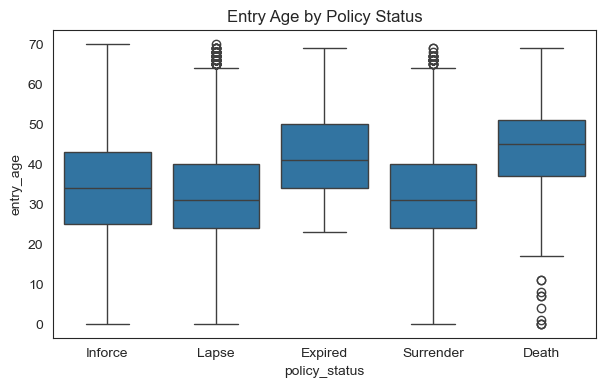

In [206]:
# Age vs Duration
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x='policy_status', y='entry_age')
plt.title('Entry Age by Policy Status')
plt.show()

In [207]:
df['policy_status'].value_counts()

policy_status
Lapse        98865
Inforce      65814
Surrender    20233
Death          513
Expired        135
Name: count, dtype: int64

## **4. Defining target variables**

In [208]:
df['event'] = df['policy_status'].apply(lambda x: 1 if x in ['Lapse', 'Surrender', 'Expired'] else 0)

# Check the breakdown
print(df['event'].value_counts())
print("\nProportions:")
print(df['event'].value_counts(normalize=True))


event
1    119233
0     66327
Name: count, dtype: int64

Proportions:
event
1    0.642558
0    0.357442
Name: proportion, dtype: float64


**Transforming the POLICY STATUS variable into a binary event indicator suitable for survival (lapse) analysis**

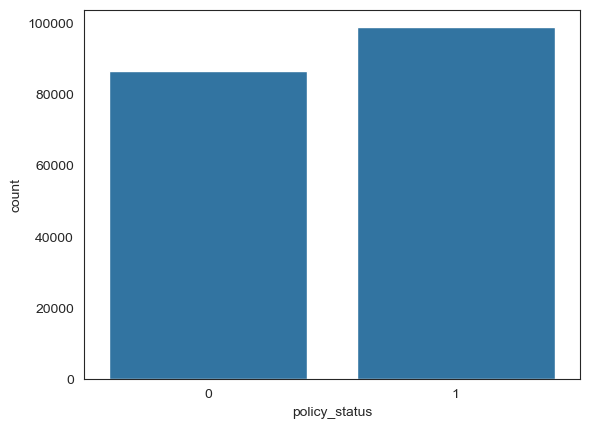

In [209]:
df['policy_status'] = (df['policy_status'] == 'Lapse').astype(int)

sns.countplot(x=df['policy_status'])
plt.show()

## **5. Data Preprocessing**

In [210]:
X_numeric = df.select_dtypes(include=['number']).drop(columns='policy_status')
X_numeric

,channel1,channel2,channel3,entry_age,policy_type_1,policy_type_2,benefit,substandard_risk,number_of_advance_premium,initial_benefit,duration,policy_year,premium,event
0,1,1,1,36,1,1,200000.0,0.0,0,0.0,8.000000,9,280.0,0
1,1,1,1,42,1,2,100000.0,0.0,0,0.0,8.000000,9,200.0,0
2,1,1,2,40,2,3,80000.0,0.0,0,0.0,8.000000,9,1289.0,1
3,1,1,3,39,1,2,100000.0,0.0,0,0.0,8.000000,9,216.0,1
4,1,1,4,44,1,2,100000.0,0.0,0,0.0,7.916667,8,140.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185555,8,3,0,31,12,58,247158.0,0.0,0,0.0,0.000000,1,5000.0,0
185556,8,3,0,36,12,58,200000.0,0.0,0,0.0,0.000000,1,4734.0,0
185557,8,3,0,24,8,52,17000.0,0.0,0,0.0,0.000000,1,432.0,0
185558,8,3,0,35,12,58,100000.0,0.0,0,0.0,0.000000,1,2023.0,0


#### **Correlation Matrix**

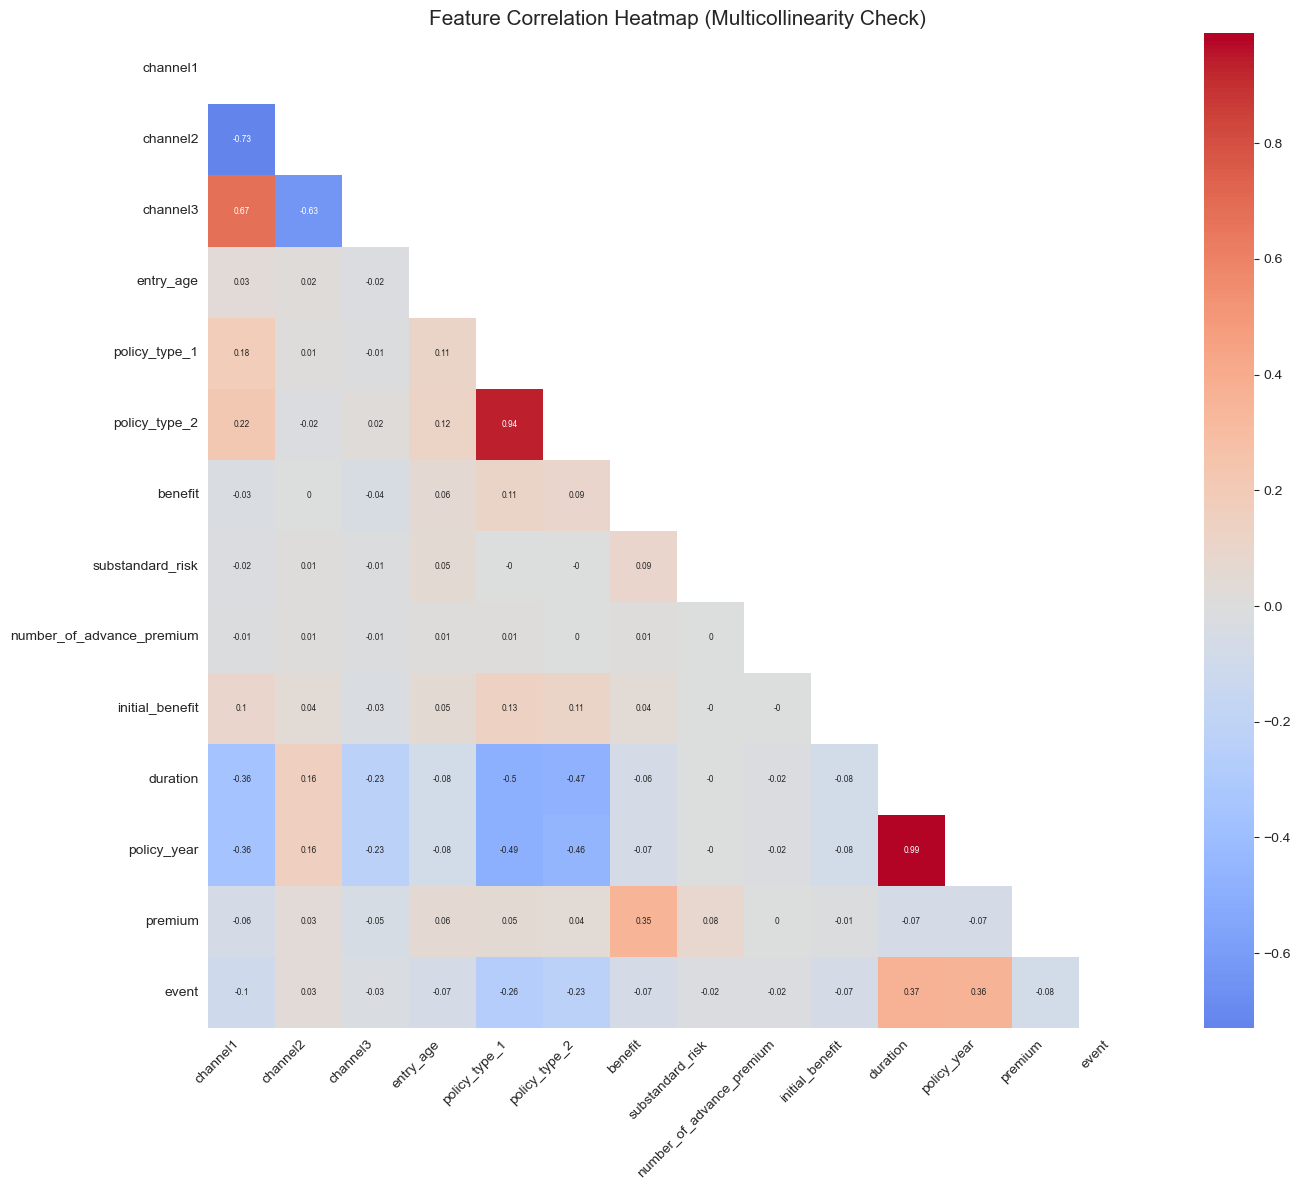

In [211]:
corr_matrix = X_numeric.corr().round(2) 

sns.set_style('white')
fig, ax = plt.subplots(figsize=(14, 12)) # Slightly wider for labels

# Creating the mask to hide the redundant upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plotting
ax = sns.heatmap(corr_matrix, mask=mask, annot=True, 
                 cmap='coolwarm', # coolwarm helps see negative correlations too
                 center=0, annot_kws={"size": 6}) 

ax.set_xticklabels(ax.xaxis.get_ticklabels(), fontsize=10, ha='right', rotation=45)
ax.set_yticklabels(ax.yaxis.get_ticklabels(), fontsize=10, va="center", rotation=0)

plt.title('Feature Correlation Heatmap (Multicollinearity Check)', fontsize=15)
plt.tight_layout()


plt.savefig('correlation_heatmap.png', dpi=300) 
plt.show()


#### **Dropping Highly correalated features**

In [212]:
correlation_threshold = 0.8

highly_correlated_features = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > correlation_threshold:
            colname = corr_matrix.columns[i]
            highly_correlated_features.add(colname)

print(f"Features to be dropped: {highly_correlated_features}")


Features to be dropped: {'policy_year', 'policy_type_2'}


In [213]:
X_numeric_reduced=X_numeric.drop(columns=highly_correlated_features)


#### **Encoding Categorical variables**

In [214]:
X_cat = df.select_dtypes(include=['object','category'])
X_cat=X_cat.drop(columns='issue_date')


In [215]:
cat_cols=X_cat.columns

X_cat_encoded = pd.get_dummies(df[cat_cols], drop_first=True, dtype=int)

##### **Concatinating Numerical and encoded categorical features**

In [216]:
df = pd.concat([X_numeric_reduced, X_cat_encoded], axis=1)

## **Definging Target Features**

In [217]:

X = df.drop(columns=['duration', 'event'])

y = np.empty(len(df), dtype=[('event', bool), ('duration', float)])
y['event'] = df['event'].astype(bool)
y['duration'] = df['duration']


#### **Training and Test split**

In [218]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (148448, 23)
Shape of X_test: (37112, 23)
Shape of y_train: (148448,)
Shape of y_test: (37112,)


## **6. MODELLING**

#### **I. COX PROPORTIONAL HAZARD MODEL**

#### **Data Preparation for model fitting**

In [219]:
#Combining X_tain and y_train features

y_df=pd.DataFrame(y_train)
y_df
df_train= pd.concat([X_train,y_df], axis=1)
df_train=df_train.dropna()

In [220]:
# Detecting Columns with zero variance
print(df_train.var()[df_train.var() == 0])

# Removing columns with zero variance
df_train = df_train.loc[:, df_train.var() != 0]

initial_benefit    0.0
dtype: object


In [221]:
# Checking variance of all columns again
print(df_train.var().min())  # Should not be 0

0.00037036720311569893


#### **Model Fitting**

In [222]:
cph = CoxPHFitter()
cph.fit(df_train, duration_col="duration", event_col="event")
cph.print_summary()


<lifelines.CoxPHFitter: fitted with 118758 total observations, 42435 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 118758
number of events observed = 76323
   partial log-likelihood = -800597.46
         time fit was run = 2025-12-29 14:03:57 UTC

---
                                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                            
channel1                            -0.00      1.00      0.00           -0.01            0.01                0.99                1.01
channel2                            -0.00      1.00      0.01           -0.02            0.02                0.98                1.02
channel3                            -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
entry_age                            0.00      1.00      0.00           -0.00            0.00                1.00                1.00
policy_type_1                        0.00      1.00      0.00           -0.00            0.00                1.00                1.00
benefit                             -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
substandard_risk                    -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
number_of_advance_premium            0.03      1.03      0.11           -0.18            0.25                0.83                1.28
premium                             -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
sex_M                                0.02      1.02      0.01            0.00            0.03                1.00                1.03
policy_type_3_B                      0.01      1.01      0.03           -0.06            0.07                0.94                1.07
policy_type_3_C                      0.01      1.01      0.01           -0.01            0.02                0.99                1.02
policy_type_3_D                      0.00      1.00      0.01           -0.02            0.03                0.98                1.03
policy_type_3_E                     -0.02      0.98      0.02           -0.05            0.02                0.95                1.02
payment_mode_Monthly                -0.01      0.99      0.01           -0.03            0.01                0.97                1.01
payment_mode_Quaterly               -0.02      0.98      0.02           -0.05            0.02                0.95                1.02
payment_mode_Semiannually            0.01      1.01      0.02           -0.04            0.06                0.97                1.06
payment_mode_Single Premium         -0.16      0.85      0.19           -0.54            0.22                0.58                1.24
non_lapse_guaranteed_NLG Not Active  0.04      1.04      0.09           -0.14            0.21                0.87                1.24
non_lapse_guaranteed_NLG Suspend     0.05      1.05      0.09           -0.11            0.22                0.89                1.25
non_lapse_guaranteed_NO NLG          0.04      1.04      0.08           -0.11            0.20                0.90                1.22
full_benefit_Y                      -0.07      0.93      0.15           -0.36            0.22                0.70                1.24

                                     cmp to     z    p  -log2(p)
covariate                                                       
channel1                               0.00 -0.10 0.92      0.12
channel2                               0.00 -0.16 0.88      0.19
channel3                               0.00 -0.82 0.41      1.28
entry_age                              0.00  0.34 0.73      0.45
policy_type_1      

### **Model Improvement**

In [229]:
#Transforming continuous variables

df_c=df_train.copy()

#df_c['log_premium'] = np.log(df_c['premium'] + 1)
#df_c['log_initial_benefit'] = np.log(df_c['initial_benefit'] + 1)

# Spline for duration
spline = dmatrix("bs(duration, df=3, include_intercept=False)", df_c, return_type="dataframe")
df_c = pd.concat([df_c, spline], axis=1)


In [230]:
df_c.isnull().sum()

channel1                               0
channel2                               0
channel3                               0
entry_age                              0
policy_type_1                          0
benefit                                0
substandard_risk                       0
number_of_advance_premium              0
premium                                0
sex_M                                  0
policy_type_3_B                        0
policy_type_3_C                        0
policy_type_3_D                        0
policy_type_3_E                        0
payment_mode_Monthly                   0
payment_mode_Quaterly                  0
payment_mode_Semiannually              0
payment_mode_Single Premium            0
non_lapse_guaranteed_NLG Not Active    0
non_lapse_guaranteed_NLG Suspend       0
non_lapse_guaranteed_NO NLG            0
full_benefit_Y                         0
event                                  0
duration                               0
dtype: int64

In [233]:
#df_c['log_premium'].fillna(df_c['log_premium'].mean(), inplace=True)

In [234]:
# Elastic Net Regularization
cph = CoxPHFitter(penalizer=0.1, l1_ratio=0.5)  # adjust penalizer if needed
cph.fit(df_c, duration_col='duration', event_col='event')
cph.print_summary()


<lifelines.CoxPHFitter: fitted with 118758 total observations, 42435 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.5
      baseline estimation = breslow
   number of observations = 118758
number of events observed = 76323
   partial log-likelihood = -800604.77
         time fit was run = 2025-12-29 14:06:50 UTC

---
                                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                            
channel1                            -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
channel2                             0.00      1.00      0.00           -0.00            0.00                1.00                1.00
channel3                            -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
entry_age                            0.00      1.00      0.00           -0.00            0.00                1.00                1.00
policy_type_1                       -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
benefit                             -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
substandard_risk                    -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
number_of_advance_premium            0.00      1.00      0.00           -0.00            0.00                1.00                1.00
premium                             -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
sex_M                                0.00      1.00      0.00           -0.00            0.00                1.00                1.00
policy_type_3_B                      0.00      1.00      0.00           -0.00            0.00                1.00                1.00
policy_type_3_C                      0.00      1.00      0.00           -0.00            0.00                1.00                1.00
policy_type_3_D                      0.00      1.00      0.00           -0.00            0.00                1.00                1.00
policy_type_3_E                     -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
payment_mode_Monthly                -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
payment_mode_Quaterly               -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
payment_mode_Semiannually            0.00      1.00      0.00           -0.00            0.00                1.00                1.00
payment_mode_Single Premium         -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
non_lapse_guaranteed_NLG Not Active -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
non_lapse_guaranteed_NLG Suspend     0.00      1.00      0.00           -0.00            0.00                1.00                1.00
non_lapse_guaranteed_NO NLG         -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
full_benefit_Y                      -0.00      1.00      0.00           -0.00            0.00                1.00                1.00

                                     cmp to     z    p  -log2(p)
covariate                                                       
channel1                               0.00 -0.01 1.00      0.01
channel2                               0.00  0.00 1.00      0.01
channel3                               0.00 -0.01 0.99      0.01
entry_age           

#### **Model Evaluation**

In [237]:
#C-INDEX

from sksurv.metrics import concordance_index_censored

y = Surv.from_dataframe('event', 'duration', df)
risk_scores = -cph.predict_partial_hazard(df)
c_index = concordance_index_censored(y['event'], y['duration'], risk_scores)[0]
print("C-index:", c_index)


C-index: 0.5877793847981823


### **Cross validation**

In [236]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
c_indices = []

for train_idx, test_idx in kf.split(df):
    train, test = df.iloc[train_idx], df.iloc[test_idx]
    cph_cv = CoxPHFitter(penalizer=0.1, l1_ratio=0.5)
    cph_cv.fit(train, duration_col='duration', event_col='event')
    risk_test = -cph_cv.predict_partial_hazard(test)
    y_test = Surv.from_dataframe('event', 'duration', test)
    c_idx = concordance_index_censored(y_test['event'], y_test['duration'], risk_test)[0]
    c_indices.append(c_idx)

print("CV Mean C-index:", np.mean(c_indices))


CV Mean C-index: 0.3523745741728087


### **COX PH Model Evaluation**

In [ ]:
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored

y = Surv.from_dataframe('event', 'duration', df)
risk_scores = -cph.predict_partial_hazard(df)
c_index = concordance_index_censored(y['event'], y['duration'], risk_scores)[0]
print("C-index:", c_index)


In [90]:
# Adding polynomial/spline for duration:
from patsy import dmatrix
spline = dmatrix("bs(duration, df=4, include_intercept=False)", df_train, return_type="dataframe")
df_train = pd.concat([df_train, spline], axis=1)


In [89]:
from lifelines import CoxPHFitter
cph = CoxPHFitter(penalizer=0.1, l1_ratio=0.5)
cph.fit(df_train, duration_col="duration", event_col="event")
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 118758 total observations, 42435 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.5
      baseline estimation = breslow
   number of observations = 118758
number of events observed = 76323
   partial log-likelihood = -724381.48
         time fit was run = 2025-12-29 13:13:33 UTC

---
                                                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                        
channel1                                        -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
channel2                                        -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
channel3                                        -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
entry_age                                        0.00      1.00      0.00           -0.00            0.00                1.00                1.00
policy_type_1                                    0.00      1.00      0.00           -0.00            0.00                1.00                1.00
benefit                                         -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
substandard_risk                                -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
number_of_advance_premium                        0.00      1.00      0.00           -0.00            0.00                1.00                1.00
premium                                         -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
sex_M                                            0.00      1.00      0.00           -0.00            0.00                1.00                1.00
policy_type_3_B                                  0.00      1.00      0.00           -0.00            0.00                1.00                1.00
policy_type_3_C                                  0.00      1.00      0.00           -0.00            0.00                1.00                1.00
policy_type_3_D                                  0.00      1.00      0.00           -0.00            0.00                1.00                1.00
policy_type_3_E                                 -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
payment_mode_Monthly                            -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
payment_mode_Quaterly                           -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
payment_mode_Semiannually                        0.00      1.00      0.00           -0.00            0.00                1.00                1.00
payment_mode_Single Premium                     -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
non_lapse_guaranteed_NLG Not Active              0.00      1.00      0.00           -0.00            0.00                1.00                1.00
non_lapse_guaranteed_NLG Suspend                -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
non_lapse_guaranteed_NO NLG                     -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
full_benefit_Y                                  -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
bs(duration, df=4, include_intercept=False)[0]   5.98    3

#### **Model Improvement**

#### **Log-transformation of monetary variables**

In [63]:
df_train["log_premium"] = np.log(df_train["premium"] + 1)
df_train["log_benefit"] = np.log(df_train["benefit"] + 1)

In [64]:
# Adding polynomial/spline for duration:
from patsy import dmatrix
spline = dmatrix("bs(duration, df=4, include_intercept=False)", df_train, return_type="dataframe")
df_train = pd.concat([df_train, spline], axis=1)


In [69]:
df_train['log_premium'].fillna(df_train['log_premium'].mean(), inplace=True)

In [71]:
# Columns with zero variance
print(df_train.var()[df_train.var() == 0])

# Remove them
df_train = df_train.loc[:, df_train.var() != 0]

# Check duplicate columns
duplicates = df_train.T.duplicated()
print(df_train.columns[duplicates])
df_train = df_train.loc[:, ~duplicates]


initial_benefit    0.0
Intercept          0.0
Intercept          0.0
dtype: object
Index(['bs(duration, df=4, include_intercept=False)[0]',
       'bs(duration, df=4, include_intercept=False)[1]',
       'bs(duration, df=4, include_intercept=False)[2]',
       'bs(duration, df=4, include_intercept=False)[3]'],
      dtype='object')


In [328]:
coxph = CoxPHSurvivalAnalysis(alpha=1e-4)

coxph.fit(X_train, y_train)

# 3. Evaluate performance
cox_c_index = coxph.score(X_test, y_test)
print(f"Cox PH Concordance Index (C-Index): {cox_c_index:.4f}")


Cox PH Concordance Index (C-Index): 0.6754


##### **Hazard Ratios**

In [331]:
results = pd.Series(coxph.coef_, index=X_train.columns)

hazard_ratios = np.exp(results)

#summary table
hr_summary = pd.DataFrame({
    "Coefficient": results,
    "Hazard Ratio (exp^coef)": hazard_ratios
}).sort_values(by="Hazard Ratio (exp^coef)", ascending=False)

print(" Hazard Ratios (Top Risk Factors)")
display(hr_summary)

 Hazard Ratios (Top Risk Factors)


,Coefficient,Hazard Ratio (exp^coef)
full_benefit_Y,0.786802,2.196362
channel2,0.537381,1.711519
payment_mode_Quaterly,0.376361,1.456973
non_lapse_guaranteed_NO NLG,0.349572,1.418460
channel1,0.346852,1.414607
payment_mode_Monthly,0.338818,1.403288
payment_mode_Semiannually,0.236517,1.266829
policy_type_3_C,0.230292,1.258967
policy_type_1,0.194586,1.214808
non_lapse_guaranteed_NLG Suspend,0.182487,1.200199


##### **Impact Visualization**

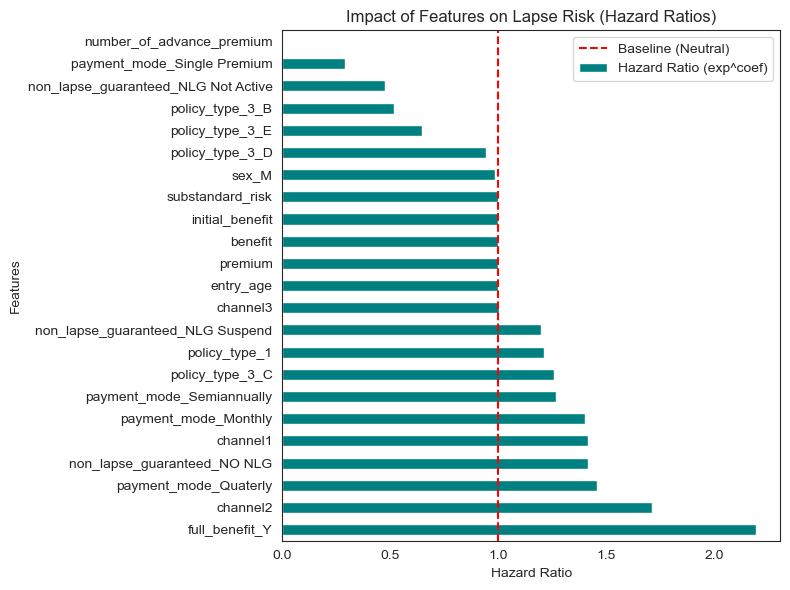

In [332]:
plt.figure(figsize=(8, 6))
hr_summary["Hazard Ratio (exp^coef)"].plot(kind='barh', color='teal')
plt.axvline(x=1, color='red', linestyle='--', label='Baseline (Neutral)')
plt.title("Impact of Features on Lapse Risk (Hazard Ratios)")
plt.xlabel("Hazard Ratio")
plt.ylabel("Features")
plt.legend()
plt.tight_layout()
plt.show()

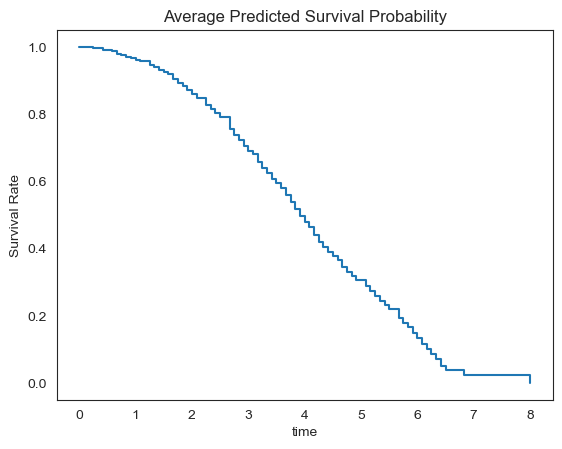

In [333]:
# Predicting survival functions for the test set
surv_funcs = coxph.predict_survival_function(X_test)

# Plot the average survival curve predicted by the model
time_points = np.percentile(y_test["duration"], np.linspace(0, 100, 100))
avg_surv = np.mean([fn(time_points) for fn in surv_funcs], axis=0)

plt.step(time_points, avg_surv, where="post")
plt.title("Average Predicted Survival Probability")
plt.xlabel("time")
plt.ylabel("Survival Rate")
plt.show()

In [335]:
# Compare the sum of predicted cumulative hazards to the actual number of events
predicted_hazard = coxph.predict(X_test).sum()
observed_events = y_test["event"].sum()

print(f"Total Predicted Events (Risk): {predicted_hazard:.2f}")
print(f"Total Observed Events: {observed_events}")

Total Predicted Events (Risk): 158796.15
Total Observed Events: 24059


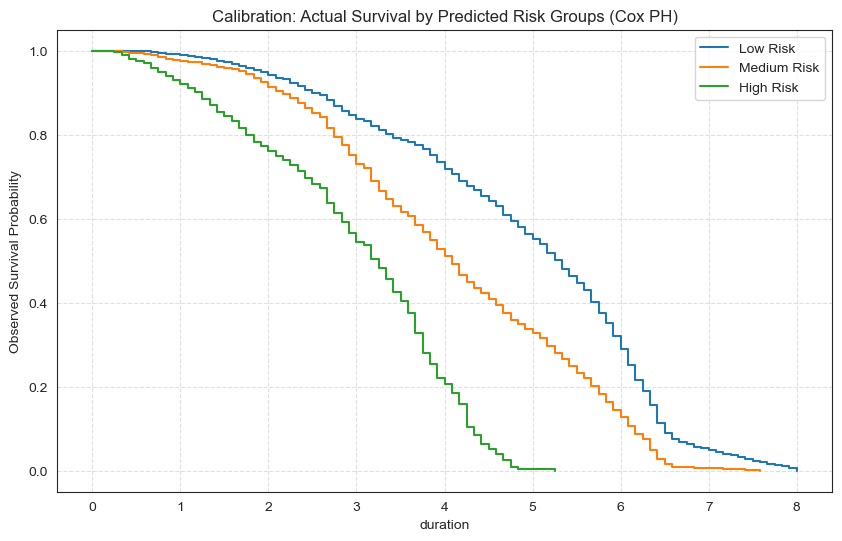

In [336]:
import matplotlib.pyplot as plt
from sksurv.nonparametric import kaplan_meier_estimator

# 1. Predict risk scores (partial hazard) for the test set
# High score = High risk of event
risk_scores = coxph.predict(X_test)

# 2. Group patients into Low, Medium, and High risk based on scores
group_labels = pd.qcut(risk_scores, q=3, labels=["Low Risk", "Medium Risk", "High Risk"])

# 3. Plot the actual Kaplan-Meier curves for these predicted groups
plt.figure(figsize=(10, 6))

for label in ["Low Risk", "Medium Risk", "High Risk"]:
    mask = (group_labels == label)
    time_group, prob_group = kaplan_meier_estimator(
        y_test["event"][mask], 
        y_test["duration"][mask]
    )
    plt.step(time_group, prob_group, where="post", label=label)

plt.title("Calibration: Actual Survival by Predicted Risk Groups (Cox PH)")
plt.xlabel("duration")
plt.ylabel("Observed Survival Probability")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Good Fit: The "Low Risk" curve (blue) stays high, the "High Risk" curve (green) drops quickly, and the "Medium Risk" is in the middle. This means $0.6547$ C-index is effectively separating patient types.

In [338]:
from sksurv.metrics import integrated_brier_score
import numpy as np

# 1. Get the range of the test set
test_min = y_test["duration"].min()
test_max = y_test["duration"].max()

# 2. Define times within the test set range
# We use a slightly tighter margin to be safe
times = np.linspace(test_min + 1, test_max - 1, 100)

# 3. Get survival functions
cox_surv_funcs = coxph.predict_survival_function(X_test)

# 4. Filter the times to ensure they are within the domain of the survival functions
# Some models might not predict out to the very end of the test set
times = np.array([t for t in times if t < y_train["duration"].max()])

# 5. Extract probabilities for these specific validated times
cox_surv_probs = np.row_stack([fn(times) for fn in cox_surv_funcs])

# 6. Calculate IBS
cox_ibs = integrated_brier_score(y_train, y_test, cox_surv_probs, times)

print(f"Cox PH C-Index: {cox_c_index:.4f}")
print(f"Cox PH Integrated Brier Score: {cox_ibs:.4f}")

Cox PH C-Index: 0.6754
Cox PH Integrated Brier Score: 0.1270


In [339]:
# 1. Initialize the RSF
# n_estimators: Number of trees to grow.
# min_samples_leaf: Minimum samples in a leaf node (prevents overfitting).
rsf = RandomSurvivalForest(
    n_estimators=100,
    min_samples_split=10,
    min_samples_leaf=15,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

# 2. Fit the model
rsf.fit(X_train, y_train)

# 3. Evaluate Performance (C-index)
rsf_c_index = rsf.score(X_test, y_test)

print(f"RSF Test C-Index: {rsf_c_index:.4f}")
#print(f"Cox PH Test C-Index (Previous): 0.6754")

RSF Test C-Index: 0.6890
Cox PH Test C-Index (Previous): 0.6754


In [340]:
#IBS

# 1. Predict survival functions for the test set
# We use the 'times' array we defined in the previous step
rsf_surv_funcs = rsf.predict_survival_function(X_test)
rsf_surv_probs = np.row_stack([fn(times) for fn in rsf_surv_funcs])

# 2. Calculate RSF IBS
rsf_ibs = integrated_brier_score(y_train, y_test, rsf_surv_probs, times)

print(f"RSF Integrated Brier Score: {rsf_ibs:.4f}")
#print(f"Cox PH IBS (Previous): 0.1270")

RSF Integrated Brier Score: 0.1014
Cox PH IBS (Previous): 0.1270


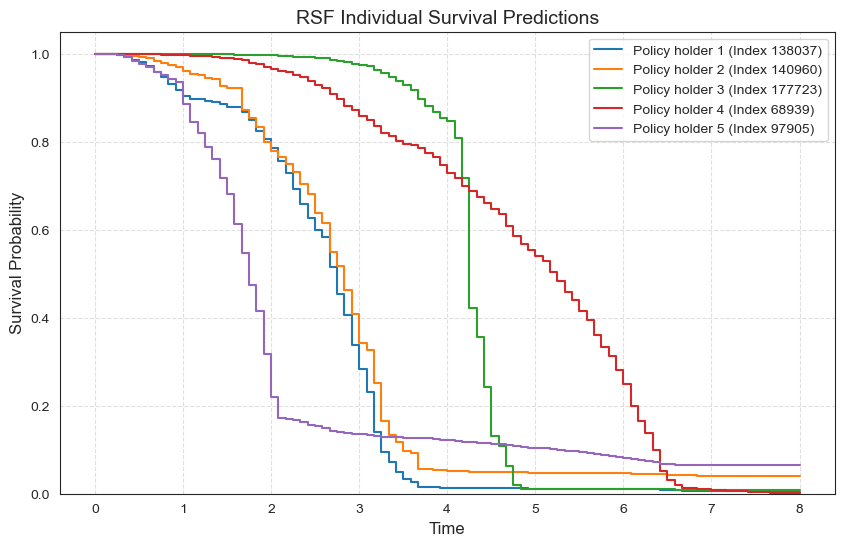

In [354]:
#INDIVIDUAL SURVIVAL CURVES

# 1. Select a few patients from the test set (e.g., first 5)
samples = X_test.iloc[:5]
surv_funcs = rsf.predict_survival_function(samples)

# 2. Plotting
plt.figure(figsize=(10, 6))

for i, s in enumerate(surv_funcs):
    plt.step(s.x, s.y, where="post", label=f"Policy holder {i+1} (Index {samples.index[i]})")

plt.title("RSF Individual Survival Predictions", fontsize=14)
plt.xlabel("Time", fontsize=12)
plt.ylabel("Survival Probability", fontsize=12)
plt.ylim(0, 1.05)
plt.grid(True, linestyle='--', alpha=0.6) # Clear Grid
plt.legend()
plt.show()

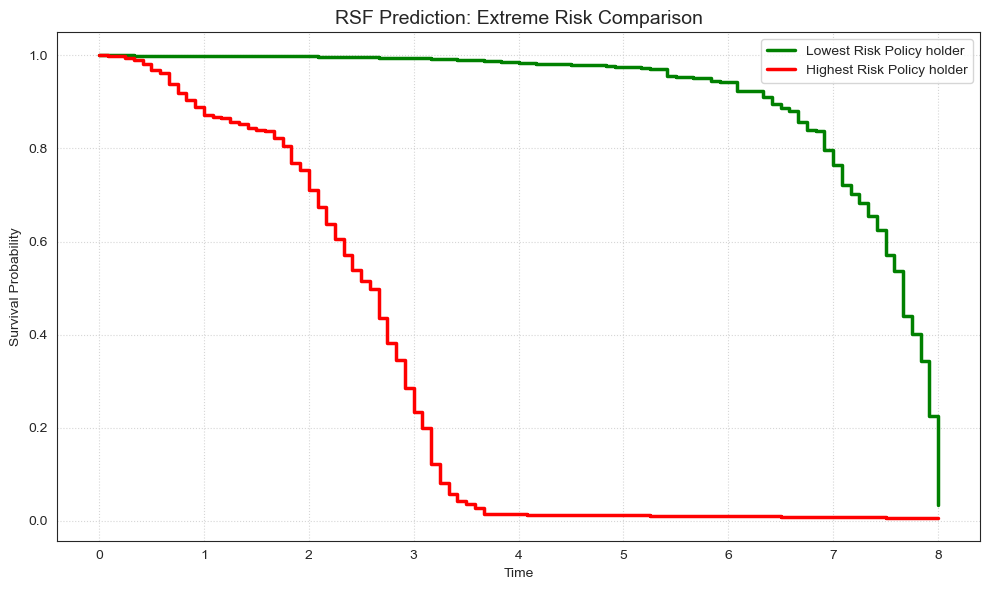

In [353]:
# High Risk vs. Low Risk Comparison


# 1. Get risk scores for everyone in the test set
risk_scores = rsf.predict(X_test)

# 2. Find the indices of the highest and lowest risk patients
idx_min = np.argmin(risk_scores)
idx_max = np.argmax(risk_scores)

# 3. Predict survival functions
extreme_samples = X_test.iloc[[idx_min, idx_max]]
extreme_surv = rsf.predict_survival_function(extreme_samples)

# 4. Plot
plt.figure(figsize=(10, 6))
labels = ['Lowest Risk Policy holder', 'Highest Risk Policy holder']
colors = ['green', 'red']

for i, s in enumerate(extreme_surv):
    plt.step(s.x, s.y, where="post", color=colors[i], label=labels[i], linewidth=2.5)

plt.title("RSF Prediction: Extreme Risk Comparison", fontsize=14)
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.grid(True, linestyle=':', alpha=0.8)
plt.legend()
plt.tight_layout()
plt.savefig('High Risk vs. Low Risk Comparison.png')
plt.show()

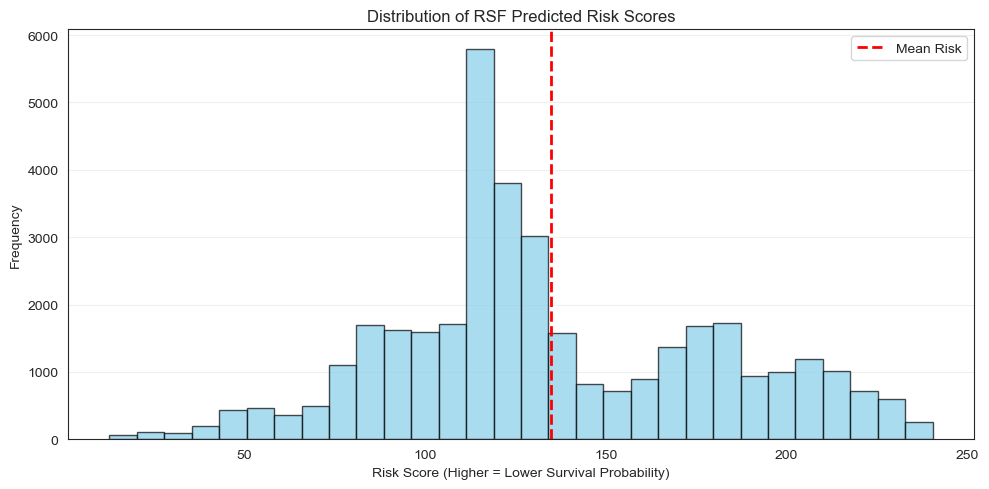

In [351]:
#DISTRIBUTION OF RISK SCORES

plt.figure(figsize=(10, 5))
plt.hist(risk_scores, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(np.mean(risk_scores), color='red', linestyle='dashed', linewidth=2, label='Mean Risk')
plt.title("Distribution of RSF Predicted Risk Scores")
plt.xlabel("Risk Score (Higher = Lower Survival Probability)")
plt.ylabel("Frequency")
plt.grid(True, axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('Distribution of risk scores.png')
plt.show()

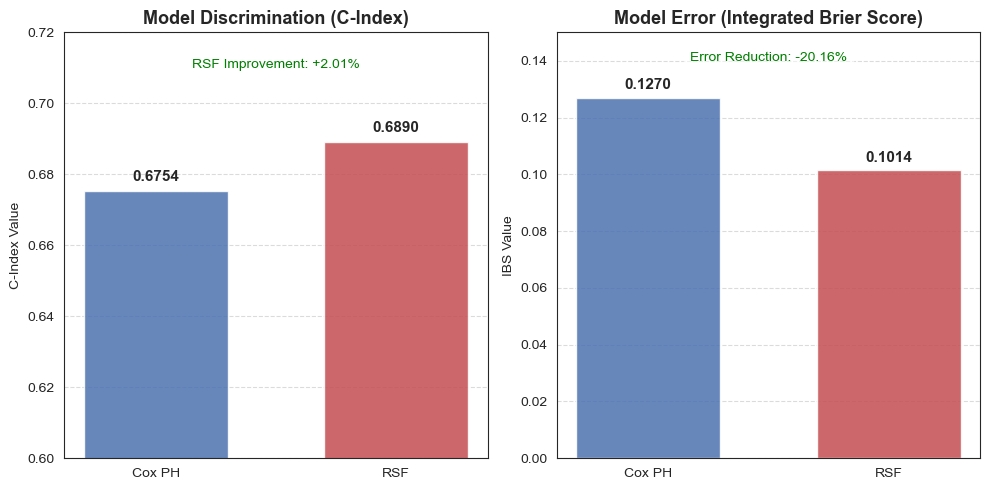

In [347]:
models = ['Cox PH', 'RSF']
c_indices = [0.6754, 0.6890]
ibs_scores = [0.1270, 0.1014]

# Colors
colors = ['#4C72B0', '#C44E52'] # Blue for Cox, Red for RSF

# Creating figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

#Plot 1: C-Index
bars1 = ax1.bar(models, c_indices, color=colors, alpha=0.85, width=0.6)
ax1.set_title('Model Discrimination (C-Index)', fontsize=13, fontweight='bold')
ax1.set_ylabel('C-Index Value')
ax1.set_ylim(0.6, 0.72) # Zoomed in to see the difference clearly
ax1.grid(True, axis='y', linestyle='--', alpha=0.7)

# Adding value labels
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.002,
             f'{height:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Calculate improvement for C-index
c_imp = ((0.6890 - 0.6754) / 0.6754) * 100
ax1.text(0.5, 0.71, f'RSF Improvement: +{c_imp:.2f}%', ha='center', color='green', fontsize=10, bbox=dict(facecolor='white', alpha=0.5))

# --- Plot 2: IBS ---
bars2 = ax2.bar(models, ibs_scores, color=colors, alpha=0.85, width=0.6)
ax2.set_title('Model Error (Integrated Brier Score)', fontsize=13, fontweight='bold')
ax2.set_ylabel('IBS Value')
ax2.set_ylim(0, 0.15)
ax2.grid(True, axis='y', linestyle='--', alpha=0.7)

# Add value labels
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.002,
             f'{height:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Calculating improvement for IBS (reduction in error)
ibs_imp = ((0.1270 - 0.1014) / 0.1270) * 100
ax2.text(0.5, 0.14, f'Error Reduction: -{ibs_imp:.2f}%', ha='center', color='green', fontsize=10, bbox=dict(facecolor='white', alpha=0.5))

plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()